In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

2026-05-25 10:38:18.371585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779705498.587202      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779705498.647025      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779705499.183318      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779705499.183350      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779705499.183353      22 computation_placer.cc:177] computation placer alr

In [3]:
## -- Set Configuration --
class CFG:
    FOLDS = 5
    SEED = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True

pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

train[TARGET] = train[TARGET].astype('int8')
orig[TARGET]  = orig[TARGET].astype('int8')

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [6]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


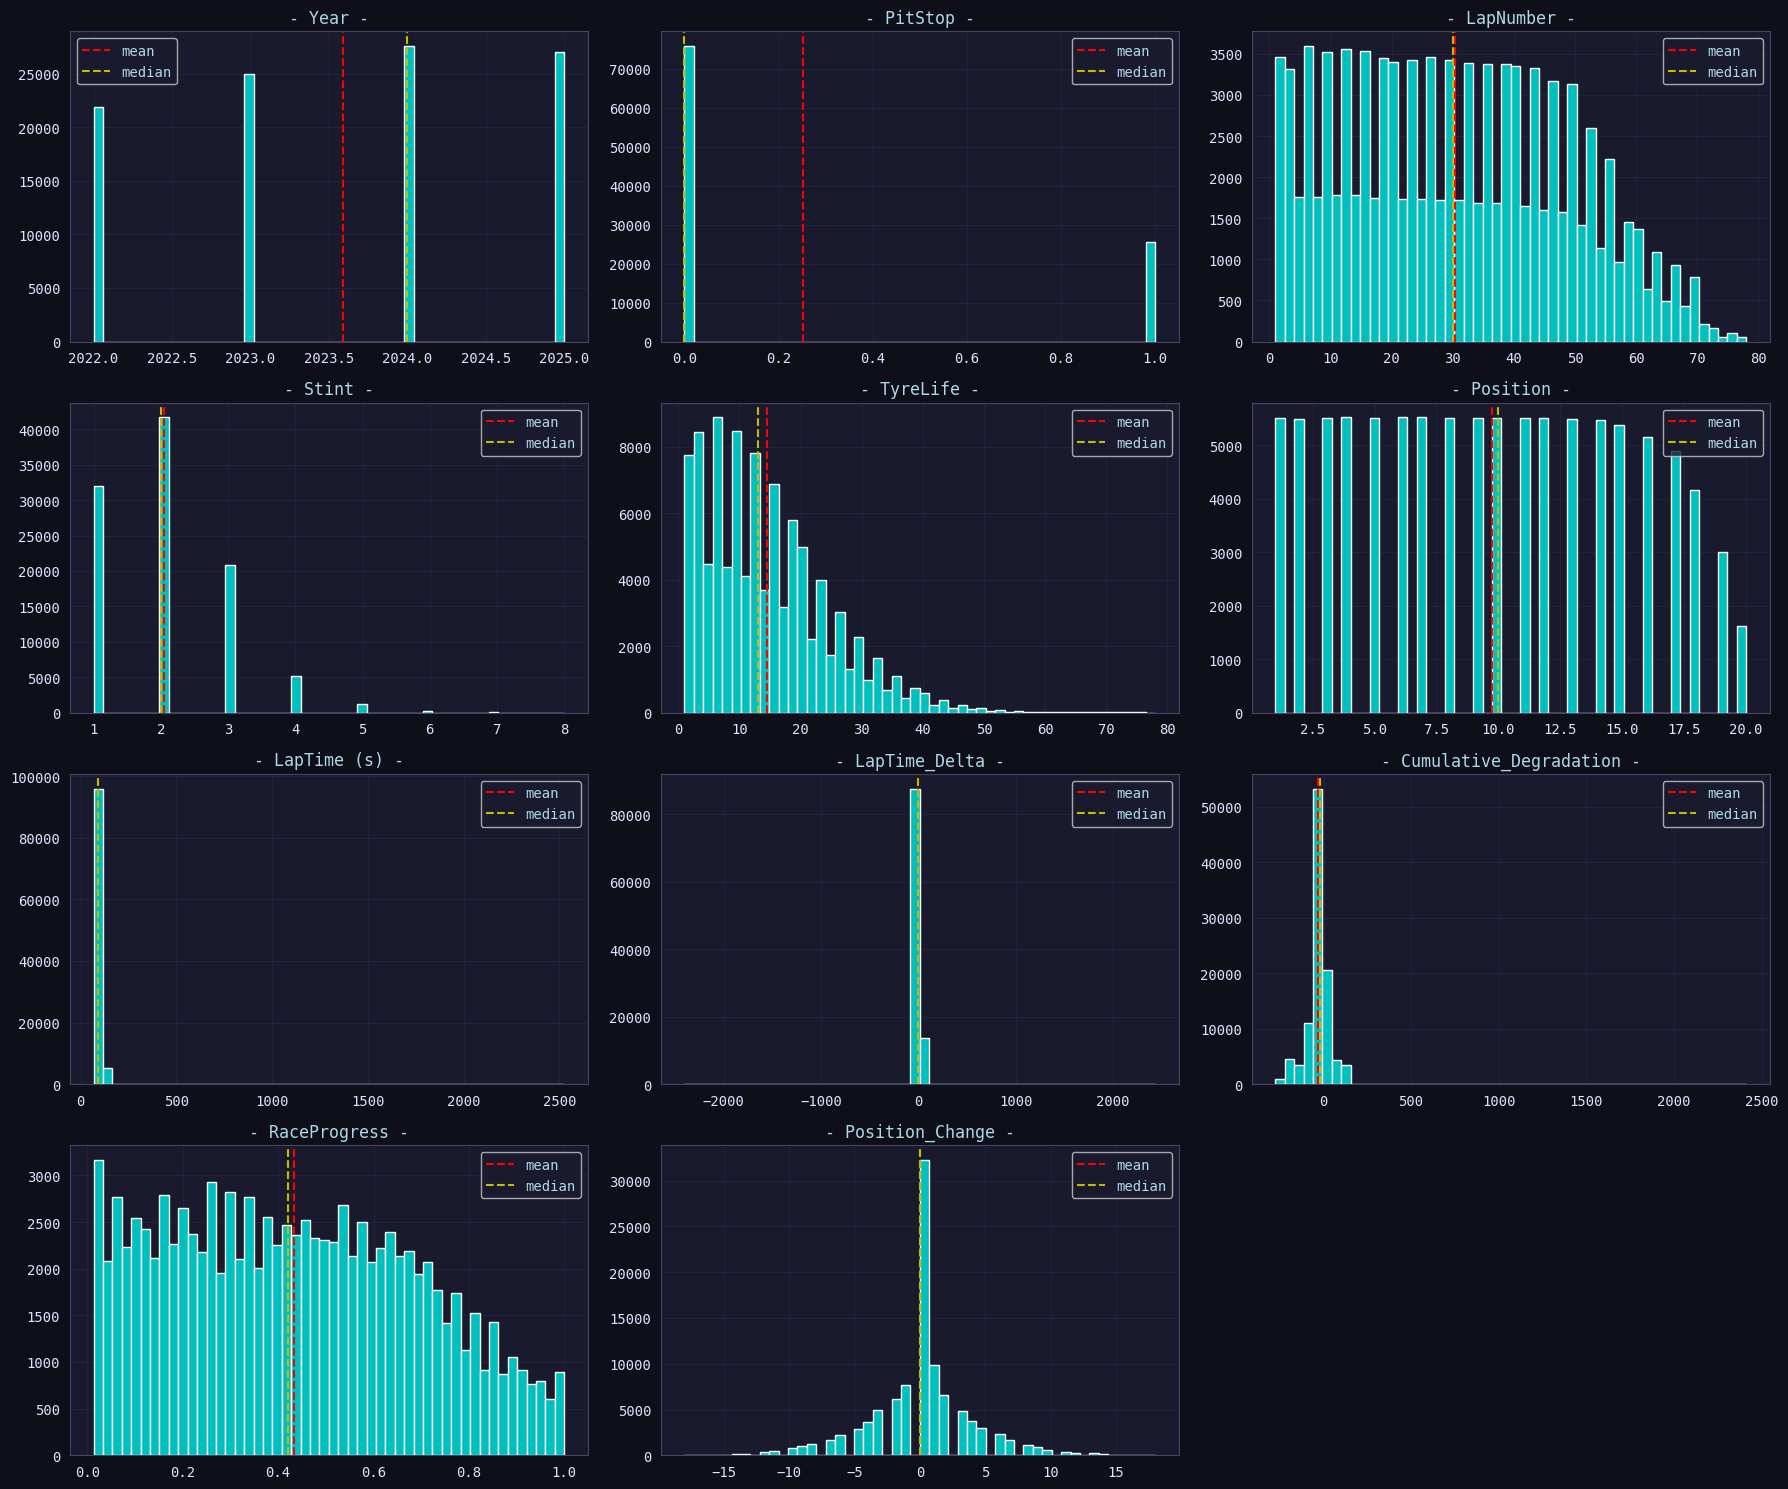

In [7]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [9]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [10]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [11]:
## -- Rounding | Digit Extractions --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
_extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

for col in _extract_cols:
    print(f"\nRounding... ", end='')
    for r in range(-2, 3):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2, 3]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


Rounding... Cumulative_Degradation_round_-2, Cumulative_Degradation_round_-1, Cumulative_Degradation_round_0, Cumulative_Degradation_round_1, Cumulative_Degradation_round_2, 
Rounding... LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, 
✅ Total ROUNDS: 10
✅ Total DIGITS: 0
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [13]:
# _extract_cols = ['TyreLife', 'Position_Change', 'LapNumber', 'Year']

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDigits... ", end='')
#     for d in [-1, 0]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [14]:
# _extract_cols = ['RaceProgress']

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDigits... ", end='')
#     for d in range(1, 7):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [17]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
INTER = []
top_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop'] # 
low_cols = ['Position', 'Position_Change', 'LapNumber', 'TyreLife']

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [19]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_div_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNumber'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_LapTime_*_Cum_Degrad'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime_*_Cum_Degrad_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime_div_Cum_Degrad_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_div_RaceProgress',
    '_TyreLife_div_LapNumber',
    '_LapTime_*_Cum_Degrad',
    '_LapTime_*_Cum_Degrad_abs',
    '_LapTime_div_Cum_Degrad_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [20]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")


Creating frequencies... Driver_freq, Compound_freq, Race_freq, LapNumber_freq, RaceProgress_freq, 
✓ Total frequency features: 5


In [21]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [22]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [25]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=n_unique.index[:10].tolist(),
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [26]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = [c for c in n_unique[n_unique < 1000].index if c not in CATS] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [27]:
## -- Factorize using combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    combined = combined.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    orig[c]  = combined[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [28]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype(int)

print('Flag Year:', 'is_2023')

Flag Year: is_2023


In [29]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 45


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs,Driver_freq,Compound_freq,Race_freq,LapNumber_freq,RaceProgress_freq,is_2023
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,0,20,21,21,21,100,80,78,78,78,2022_HARD,2022_2,2022_Canadian Grand Prix,2022_0,HARD_2,HARD_Canadian Grand Prix,HARD_0,2_Canadian Grand Prix,2_0,Canadian Grand Prix_0,69.999901,0.780000,1649.802368,1649.802368,3.734288,0.002034,0.395496,0.048945,0.011480,0.000915,0
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,-200,-220,-223,-223,-223,100,80,75,75,75,2025_HARD,2025_2,2025_Dutch Grand Prix,2025_1,HARD_2,HARD_Dutch Grand Prix,HARD_1,2_Dutch Grand Prix,2_1,Dutch Grand Prix_1,77.999771,0.259259,-16761.730469,16761.730469,0.336437,0.002207,0.395496,0.055289,0.012781,0.002768,0
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,-100,-100,-101,-100,-100,100,70,71,70,70,2022_HARD,2022_3,2022_Austrian Grand Prix,2022_0,HARD_3,HARD_Austrian Grand Prix,HARD_0,3_Austrian Grand Prix,3_0,Austrian Grand Prix_0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,0.002893,0.395496,0.047861,0.003255,0.001118,0


# ML TRAINING

In [30]:
try:
    import catboost as cgb
except:
    %pip install -q catboost
    import catboost as cgb

# try:
#     from venn_abers import VennAbersCalibrator
# except:
#     %pip install -q venn-abers
#     from venn_abers import VennAbersCalibrator

# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -q cir-model
#     from cir_model import CenteredIsotonicRegression

print('CatBoost version:', cgb.__version__)

CatBoost version: 1.2.10


In [31]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]

        X_test = test_df[features].copy()

        ## -- OPTION A: Concatenate original data --
        X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_features = ROUNDS
        # cme_cols = []

        # ce_cols = ['Driver', 'Position']
        # print(f" • Cat_Mean Encoding {len(ce_cols)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=ce_cols)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_valid = TE.transform(X_valid)
        # X_test  = TE.transform(X_test)

        all_categorical = cats
        combined = pd.concat([X_train, X_valid, X_test])
        
        for c in all_categorical:
            combined[c] = combined[c].astype('str')

        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} *****")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=50_000,
            eval_set=dval,
            early_stopping_rounds=200,
            verbose=1000,
        )

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1]
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1]

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG.YELLOW} • Fold {idx+1} Score: {fold_score:.5f}{CFG.RESET}')

        ## -- Clean up memory --
        del X_train, y_train, y_valid, X_test, dtrain, dval, dtest, combined
        gc.collect()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} Score: {score:.5f}")

    ## -- Calculate out-of-fold Score --
    final_score = np.round(roc_auc_score(y, oof_preds), 5)

    print("-------------------------------------------------|")
    print(f"Overall Score: {final_score}")
    print(f"Average Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': final_score,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [32]:
version_name = 'cat_orig_'
all_model_predictions = {}

MULTI_SEEDS = [CFG.SEED] #, 777, 1234, 24611, 0]
ALL_CATS = CATS + ROUNDS + INTER # ['Year', 'Stint'] + ['PitStop', 'is_2023']

kf = StratifiedKFold(n_splits=CFG.FOLDS, shuffle=True, random_state=CFG.SEED)
kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [33]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = '_'
# COMPILER = []

# OUT_LOOP = [4, 5]
# INN_LOOP = [0]
# p_name   = ['l2', '-']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': 0.5,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.1,
#             'depth': 6,
#             'l2_leaf_reg': outer,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': CFG.SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=ALL_CATS,
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n===== Results ready for {len(COMPILER)} models =====")

In [34]:
# CatBoostTE (INTER + ROUNDS) =====================
# Cross-Validation Results for _l2=4__-=0
# ==================================================
#  • Fold 1 Score: 0.95261
#  • Fold 2 Score: 0.95069
#  • Fold 3 Score: 0.95187
#  • Fold 4 Score: 0.95086
#  • Fold 5 Score: 0.95228
# -------------------------------------------------|
# Overall Score: 0.95165
# Average Score: 0.95166 ± 0.00076
# -------------------------------------------------|
# 16.64 mins

In [35]:
# ## -- Get Scores --
# all_model_scores = {}
# all_scores = []

# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             all_model_scores[k] = y
#             all_scores.append(float(y))

# # fig, ax = plt.subplots(figsize=(15, 5))
# # ax.plot(all_model_scores.keys(), all_model_scores.values(), marker='o')

# plt.figure(figsize=(16, 5))
# ax = sns.lineplot(all_model_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# ax.set_ylim(0.94, 0.955)

# for i, s in enumerate(all_model_scores.values()):
#     ax.text(float(i), s+1e-3, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

In [36]:
LR = 0.03
L2_REG = 4.0

LR, L2_REG

(0.03, 4.0)

In [37]:
## ===== BAYES =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_strength': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'random_state': CFG.SEED,
    'thread_count': os.cpu_count(),
    'verbose': 0,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}
n = f"{version_name}bayes_"

# for b_seed in MULTI_SEEDS:
#     PARAMS['random_state'] = b_seed
#     n = f"{version_name}bayes_" + str(b_seed)
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)


========== Starting Cross-Validation for cat_orig_bayes_ ==========

***** FOLD 1/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9191319	best: 0.9191319 (0)	total: 218ms	remaining: 3h 1m 25s
1000:	test: 0.9498031	best: 0.9498031 (1000)	total: 1m 9s	remaining: 56m 43s
2000:	test: 0.9514642	best: 0.9514648 (1999)	total: 2m 20s	remaining: 56m 20s
3000:	test: 0.9522221	best: 0.9522221 (3000)	total: 3m 32s	remaining: 55m 20s
4000:	test: 0.9526078	best: 0.9526078 (4000)	total: 4m 44s	remaining: 54m 26s
5000:	test: 0.9529145	best: 0.9529145 (4999)	total: 5m 56s	remaining: 53m 29s
6000:	test: 0.9531035	best: 0.9531057 (5995)	total: 7m 9s	remaining: 52m 26s
7000:	test: 0.9532455	best: 0.9532483 (6982)	total: 8m 22s	remaining: 51m 27s
8000:	test: 0.9533719	best: 0.9533727 (7995)	total: 9m 36s	remaining: 50m 27s
9000:	test: 0.9534444	best: 0.9534487 (8940)	total: 10m 50s	remaining: 49m 23s
10000:	test: 0.9534985	best: 0.9535009 (9968)	total: 12m 5s	remaining: 48m 22s
11000:	test: 0.9535480	best: 0.9535537 (10908)	total: 13m 20s	remaining: 47m 19s
bestTest = 0.9535757303
bestIteration = 11573
Shrink model to firs

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9171950	best: 0.9171950 (0)	total: 105ms	remaining: 1h 27m 10s
1000:	test: 0.9477800	best: 0.9477800 (1000)	total: 1m 11s	remaining: 58m 30s
2000:	test: 0.9493735	best: 0.9493737 (1999)	total: 2m 23s	remaining: 57m 24s
3000:	test: 0.9500718	best: 0.9500718 (3000)	total: 3m 35s	remaining: 56m 15s
4000:	test: 0.9504719	best: 0.9504719 (4000)	total: 4m 47s	remaining: 55m 5s
5000:	test: 0.9507403	best: 0.9507403 (5000)	total: 6m	remaining: 53m 59s
6000:	test: 0.9509511	best: 0.9509511 (6000)	total: 7m 12s	remaining: 52m 51s
7000:	test: 0.9510965	best: 0.9510974 (6997)	total: 8m 25s	remaining: 51m 47s
8000:	test: 0.9511927	best: 0.9511961 (7864)	total: 9m 39s	remaining: 50m 39s
9000:	test: 0.9512607	best: 0.9512609 (8999)	total: 10m 53s	remaining: 49m 35s
10000:	test: 0.9513425	best: 0.9513425 (10000)	total: 12m 8s	remaining: 48m 31s
11000:	test: 0.9513885	best: 0.9513894 (10995)	total: 13m 23s	remaining: 47m 29s
12000:	test: 0.9514403	best: 0.9514413 (11989)	total: 14m 39s	remai

...

0:	test: 0.9195068	best: 0.9195068 (0)	total: 106ms	remaining: 1h 27m 55s
1000:	test: 0.9493911	best: 0.9493918 (999)	total: 1m 12s	remaining: 58m 58s
2000:	test: 0.9509107	best: 0.9509107 (2000)	total: 2m 23s	remaining: 57m 31s
3000:	test: 0.9515468	best: 0.9515468 (3000)	total: 3m 35s	remaining: 56m 21s
4000:	test: 0.9518883	best: 0.9518884 (3998)	total: 4m 48s	remaining: 55m 12s
5000:	test: 0.9521507	best: 0.9521518 (4994)	total: 6m	remaining: 54m 5s
6000:	test: 0.9523061	best: 0.9523077 (5995)	total: 7m 14s	remaining: 53m 3s
7000:	test: 0.9524229	best: 0.9524229 (7000)	total: 8m 27s	remaining: 51m 58s
8000:	test: 0.9525285	best: 0.9525292 (7989)	total: 9m 41s	remaining: 50m 54s
9000:	test: 0.9525896	best: 0.9525968 (8807)	total: 10m 56s	remaining: 49m 50s
bestTest = 0.9525968432
bestIteration = 8807
Shrink model to first 8808 iterations.
 • Fold 3 Score: 0.95260

***** FOLD 4/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9176337	best: 0.9176337 (0)	total: 105ms	remaining: 1h 27m 41s
1000:	test: 0.9477627	best: 0.9477627 (1000)	total: 1m 11s	remaining: 58m 26s
2000:	test: 0.9494704	best: 0.9494704 (2000)	total: 2m 22s	remaining: 57m 4s
3000:	test: 0.9502069	best: 0.9502069 (3000)	total: 3m 34s	remaining: 55m 57s
4000:	test: 0.9506330	best: 0.9506330 (4000)	total: 4m 46s	remaining: 54m 52s
5000:	test: 0.9509355	best: 0.9509361 (4999)	total: 5m 58s	remaining: 53m 47s
6000:	test: 0.9511443	best: 0.9511451 (5987)	total: 7m 11s	remaining: 52m 45s
7000:	test: 0.9513001	best: 0.9513010 (6991)	total: 8m 25s	remaining: 51m 46s
8000:	test: 0.9514252	best: 0.9514258 (7995)	total: 9m 39s	remaining: 50m 40s
9000:	test: 0.9515386	best: 0.9515388 (8932)	total: 10m 53s	remaining: 49m 36s
10000:	test: 0.9516031	best: 0.9516065 (9910)	total: 12m 8s	remaining: 48m 32s
11000:	test: 0.9516802	best: 0.9516802 (10999)	total: 13m 23s	remaining: 47m 29s
bestTest = 0.9516827464
bestIteration = 11010
Shrink model to fi

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9196188	best: 0.9196188 (0)	total: 106ms	remaining: 1h 28m 3s
1000:	test: 0.9494050	best: 0.9494050 (1000)	total: 1m 11s	remaining: 58m 33s
2000:	test: 0.9511942	best: 0.9511942 (2000)	total: 2m 22s	remaining: 57m
3000:	test: 0.9519417	best: 0.9519417 (3000)	total: 3m 34s	remaining: 55m 52s
4000:	test: 0.9523309	best: 0.9523315 (3996)	total: 4m 45s	remaining: 54m 47s
5000:	test: 0.9526282	best: 0.9526291 (4966)	total: 5m 58s	remaining: 53m 43s
6000:	test: 0.9528137	best: 0.9528137 (6000)	total: 7m 10s	remaining: 52m 37s
7000:	test: 0.9529776	best: 0.9529776 (6996)	total: 8m 24s	remaining: 51m 35s
8000:	test: 0.9530917	best: 0.9530920 (7997)	total: 9m 38s	remaining: 50m 34s
9000:	test: 0.9531949	best: 0.9531962 (8992)	total: 10m 52s	remaining: 49m 30s
10000:	test: 0.9532598	best: 0.9532617 (9981)	total: 12m 7s	remaining: 48m 27s
bestTest = 0.953266263
bestIteration = 10132
Shrink model to first 10133 iterations.
 • Fold 5 Score: 0.95327

Cross-Validation Results for cat_orig_

In [38]:
# ## ===== MVS =====

# PARAMS = {
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # def= 0.8
#     # ---------------------------------
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': LR,
#     # 'depth': 6,
#     'l2_leaf_reg': L2_REG,
#     'random_state': CFG.SEED,
#     'thread_count': os.cpu_count(),
#     'verbose': 0,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# for m_seed in MULTI_SEEDS:
#     PARAMS['random_state'] = m_seed
#     n = f"{version_name}mvs_" #+ str(be_seed)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=ALL_CATS,
#     )

In [39]:
## ===== BERNOULLI =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Depthwise',
    # ---------------------------------
    'bootstrap_type': 'Bernoulli',
    # 'subsample': 0.8, # def= 0.66
    # 'colsample_bylevel': 0.7,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'random_state': CFG.SEED,
    'thread_count': os.cpu_count(),
    'verbose': 0,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for be_seed in MULTI_SEEDS:
    PARAMS['random_state'] = be_seed
    n = f"{version_name}bern_" #+ str(be_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_orig_bern_ ==========

***** FOLD 1/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9301455	best: 0.9301455 (0)	total: 116ms	remaining: 1h 36m 28s
1000:	test: 0.9510122	best: 0.9510122 (1000)	total: 22.6s	remaining: 18m 28s
2000:	test: 0.9526322	best: 0.9526322 (2000)	total: 45.9s	remaining: 18m 21s
3000:	test: 0.9533401	best: 0.9533405 (2998)	total: 1m 8s	remaining: 17m 56s
4000:	test: 0.9536893	best: 0.9536908 (3999)	total: 1m 31s	remaining: 17m 33s
5000:	test: 0.9538153	best: 0.9538168 (4992)	total: 1m 54s	remaining: 17m 14s
bestTest = 0.9538602233
bestIteration = 5397
Shrink model to first 5398 iterations.
 • Fold 1 Score: 0.95386

***** FOLD 2/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9280461	best: 0.9280461 (0)	total: 42ms	remaining: 34m 59s
1000:	test: 0.9490656	best: 0.9490656 (1000)	total: 22.6s	remaining: 18m 26s
2000:	test: 0.9505539	best: 0.9505539 (2000)	total: 45.7s	remaining: 18m 16s
3000:	test: 0.9511569	best: 0.9511569 (3000)	total: 1m 8s	remaining: 17m 46s
4000:	test: 0.9514142	best: 0.9514170 (3983)	total: 1m 31s	remaining: 17m 28s
bestTest = 0.951439321
bestIteration = 4328
Shrink model to first 4329 iterations.
 • Fold 2 Score: 0.95144

***** FOLD 3/5 - Train shape: (452683, 45) *****


...

0:	test: 0.9302785	best: 0.9302785 (0)	total: 36.9ms	remaining: 30m 44s
1000:	test: 0.9503292	best: 0.9503292 (1000)	total: 22.4s	remaining: 18m 18s
2000:	test: 0.9518051	best: 0.9518051 (2000)	total: 45.3s	remaining: 18m 6s
3000:	test: 0.9523855	best: 0.9523855 (3000)	total: 1m 8s	remaining: 17m 55s
4000:	test: 0.9526562	best: 0.9526568 (3984)	total: 1m 31s	remaining: 17m 32s
5000:	test: 0.9527482	best: 0.9527525 (4859)	total: 1m 54s	remaining: 17m 9s
6000:	test: 0.9527911	best: 0.9527979 (5866)	total: 2m 17s	remaining: 16m 49s
bestTest = 0.9527978897
bestIteration = 5866
Shrink model to first 5867 iterations.
 • Fold 3 Score: 0.95280

***** FOLD 4/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9293233	best: 0.9293233 (0)	total: 39.6ms	remaining: 33m
1000:	test: 0.9493521	best: 0.9493521 (1000)	total: 22.6s	remaining: 18m 27s
2000:	test: 0.9509564	best: 0.9509564 (2000)	total: 45.7s	remaining: 18m 15s
3000:	test: 0.9516526	best: 0.9516526 (3000)	total: 1m 8s	remaining: 17m 56s
4000:	test: 0.9520289	best: 0.9520289 (4000)	total: 1m 31s	remaining: 17m 32s
5000:	test: 0.9521720	best: 0.9521738 (4995)	total: 1m 54s	remaining: 17m 14s
bestTest = 0.9522069693
bestIteration = 5306
Shrink model to first 5307 iterations.
 • Fold 4 Score: 0.95221

***** FOLD 5/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9295241	best: 0.9295241 (0)	total: 39.2ms	remaining: 32m 38s
1000:	test: 0.9503527	best: 0.9503527 (1000)	total: 23.3s	remaining: 19m 2s
2000:	test: 0.9519464	best: 0.9519470 (1999)	total: 45.8s	remaining: 18m 19s
3000:	test: 0.9525775	best: 0.9525775 (3000)	total: 1m 9s	remaining: 18m
4000:	test: 0.9529108	best: 0.9529108 (4000)	total: 1m 32s	remaining: 17m 42s
5000:	test: 0.9530591	best: 0.9530643 (4994)	total: 1m 55s	remaining: 17m 22s
bestTest = 0.9531186223
bestIteration = 5565
Shrink model to first 5566 iterations.
 • Fold 5 Score: 0.95312

Cross-Validation Results for cat_orig_bern_
 • Fold 1 Score: 0.95386
 • Fold 2 Score: 0.95144
 • Fold 3 Score: 0.95280
 • Fold 4 Score: 0.95221
 • Fold 5 Score: 0.95312
-------------------------------------------------|
Overall Score: 0.95268
Average Score: 0.95268 ± 0.00082
-------------------------------------------------|
12.63 mins



In [40]:
## ===== LOSS =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Lossguide',
    # ---------------------------------
    'max_leaves': 64,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'random_state': CFG.SEED,
    'thread_count': os.cpu_count(),
    'verbose': 0,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for l_seed in MULTI_SEEDS:
    PARAMS['random_state'] = l_seed
    n = f"{version_name}loss_" #+ str(l_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_orig_loss_ ==========

***** FOLD 1/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9296883	best: 0.9296883 (0)	total: 63.5ms	remaining: 52m 54s
1000:	test: 0.9520429	best: 0.9520429 (1000)	total: 46.3s	remaining: 37m 44s
2000:	test: 0.9533648	best: 0.9533648 (2000)	total: 1m 29s	remaining: 35m 52s
3000:	test: 0.9537948	best: 0.9537948 (3000)	total: 2m 12s	remaining: 34m 37s
4000:	test: 0.9539510	best: 0.9539548 (3921)	total: 2m 57s	remaining: 33m 55s
bestTest = 0.9539591074
bestIteration = 4050
Shrink model to first 4051 iterations.
 • Fold 1 Score: 0.95396

***** FOLD 2/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9274749	best: 0.9274749 (0)	total: 61.2ms	remaining: 50m 59s
1000:	test: 0.9502024	best: 0.9502024 (1000)	total: 44.9s	remaining: 36m 35s
2000:	test: 0.9513955	best: 0.9513965 (1994)	total: 1m 33s	remaining: 37m 25s
3000:	test: 0.9517629	best: 0.9517722 (2966)	total: 2m 23s	remaining: 37m 33s
4000:	test: 0.9518326	best: 0.9518503 (3950)	total: 3m 8s	remaining: 36m 2s
bestTest = 0.9518502951
bestIteration = 3950
Shrink model to first 3951 iterations.
 • Fold 2 Score: 0.95185

***** FOLD 3/5 - Train shape: (452683, 45) *****


...

0:	test: 0.9294055	best: 0.9294055 (0)	total: 61.5ms	remaining: 51m 13s
1000:	test: 0.9513738	best: 0.9513738 (1000)	total: 48.2s	remaining: 39m 18s
2000:	test: 0.9524117	best: 0.9524125 (1998)	total: 1m 37s	remaining: 38m 47s
3000:	test: 0.9527456	best: 0.9527456 (3000)	total: 2m 26s	remaining: 38m 10s
4000:	test: 0.9528674	best: 0.9528702 (3972)	total: 3m 12s	remaining: 36m 55s
bestTest = 0.952891469
bestIteration = 4445
Shrink model to first 4446 iterations.
 • Fold 3 Score: 0.95289

***** FOLD 4/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9292406	best: 0.9292406 (0)	total: 60ms	remaining: 50m 1s
1000:	test: 0.9506592	best: 0.9506592 (1000)	total: 44.6s	remaining: 36m 21s
2000:	test: 0.9518809	best: 0.9518809 (2000)	total: 1m 26s	remaining: 34m 36s
3000:	test: 0.9522983	best: 0.9523040 (2973)	total: 2m 15s	remaining: 35m 16s
4000:	test: 0.9524372	best: 0.9524395 (3986)	total: 3m 3s	remaining: 35m 11s
bestTest = 0.9525076151
bestIteration = 4790
Shrink model to first 4791 iterations.
 • Fold 4 Score: 0.95251

***** FOLD 5/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9291218	best: 0.9291218 (0)	total: 59.6ms	remaining: 49m 40s
1000:	test: 0.9519246	best: 0.9519246 (1000)	total: 48.7s	remaining: 39m 43s
2000:	test: 0.9531721	best: 0.9531722 (1997)	total: 1m 33s	remaining: 37m 11s
3000:	test: 0.9535356	best: 0.9535356 (2994)	total: 2m 20s	remaining: 36m 36s
4000:	test: 0.9536576	best: 0.9536600 (3912)	total: 3m 6s	remaining: 35m 47s
bestTest = 0.9536933303
bestIteration = 4611
Shrink model to first 4612 iterations.
 • Fold 5 Score: 0.95369

Cross-Validation Results for cat_orig_loss_
 • Fold 1 Score: 0.95396
 • Fold 2 Score: 0.95185
 • Fold 3 Score: 0.95289
 • Fold 4 Score: 0.95251
 • Fold 5 Score: 0.95369
-------------------------------------------------|
Overall Score: 0.95297
Average Score: 0.95298 ± 0.00077
-------------------------------------------------|
19.67 mins



In [41]:
## ===== ORDERED =====

PARAMS = {
    'boosting_type': 'Ordered',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'random_state': CFG.SEED,
    'thread_count': os.cpu_count(),
    'verbose': 0,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for or_seed in MULTI_SEEDS:
    PARAMS['random_state'] = or_seed
    n = f"{version_name}ord_bayes_" #+ str(or_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_orig_ord_bayes_ ==========

***** FOLD 1/5 - Train shape: (452683, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9191319	best: 0.9191319 (0)	total: 217ms	remaining: 3h 49s
1000:	test: 0.9494721	best: 0.9494721 (1000)	total: 2m 6s	remaining: 1h 42m 48s
2000:	test: 0.9506134	best: 0.9506134 (2000)	total: 4m 2s	remaining: 1h 36m 51s
3000:	test: 0.9511187	best: 0.9511187 (2996)	total: 5m 56s	remaining: 1h 33m 10s
4000:	test: 0.9515029	best: 0.9515029 (4000)	total: 7m 51s	remaining: 1h 30m 23s
5000:	test: 0.9517210	best: 0.9517210 (5000)	total: 9m 46s	remaining: 1h 27m 58s
6000:	test: 0.9519249	best: 0.9519255 (5985)	total: 11m 41s	remaining: 1h 25m 43s
7000:	test: 0.9520680	best: 0.9520680 (6998)	total: 13m 36s	remaining: 1h 23m 34s
8000:	test: 0.9521316	best: 0.9521320 (7976)	total: 15m 28s	remaining: 1h 21m 14s
9000:	test: 0.9521999	best: 0.9522002 (8985)	total: 17m 20s	remaining: 1h 18m 58s
10000:	test: 0.9522664	best: 0.9522664 (10000)	total: 19m 14s	remaining: 1h 16m 57s
11000:	test: 0.9523351	best: 0.9523352 (10998)	total: 21m 10s	remaining: 1h 15m 3s
12000:	test: 0.9523679	best: 0.9

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9152154	best: 0.9152154 (0)	total: 210ms	remaining: 2h 54m 36s
1000:	test: 0.9473357	best: 0.9473357 (998)	total: 2m 5s	remaining: 1h 42m 22s
2000:	test: 0.9487677	best: 0.9487677 (2000)	total: 4m 5s	remaining: 1h 38m 8s
3000:	test: 0.9494328	best: 0.9494328 (2999)	total: 6m 3s	remaining: 1h 34m 45s
4000:	test: 0.9497238	best: 0.9497241 (3998)	total: 7m 56s	remaining: 1h 31m 21s
5000:	test: 0.9499775	best: 0.9499775 (5000)	total: 9m 52s	remaining: 1h 28m 54s
6000:	test: 0.9502039	best: 0.9502039 (6000)	total: 11m 49s	remaining: 1h 26m 42s
7000:	test: 0.9503489	best: 0.9503492 (6980)	total: 13m 47s	remaining: 1h 24m 42s
8000:	test: 0.9504552	best: 0.9504552 (8000)	total: 15m 46s	remaining: 1h 22m 49s
9000:	test: 0.9505337	best: 0.9505342 (8993)	total: 17m 43s	remaining: 1h 20m 45s
10000:	test: 0.9505925	best: 0.9505929 (9997)	total: 19m 41s	remaining: 1h 18m 44s
11000:	test: 0.9506497	best: 0.9506497 (10999)	total: 21m 41s	remaining: 1h 16m 52s
12000:	test: 0.9506859	best: 0.

...

0:	test: 0.9163871	best: 0.9163871 (0)	total: 194ms	remaining: 2h 41m 15s
1000:	test: 0.9492622	best: 0.9492622 (1000)	total: 2m 6s	remaining: 1h 43m 4s
2000:	test: 0.9503922	best: 0.9503922 (2000)	total: 4m 6s	remaining: 1h 38m 22s
3000:	test: 0.9509266	best: 0.9509266 (2997)	total: 6m 3s	remaining: 1h 34m 49s
4000:	test: 0.9512299	best: 0.9512299 (4000)	total: 7m 58s	remaining: 1h 31m 45s
5000:	test: 0.9514393	best: 0.9514393 (5000)	total: 9m 53s	remaining: 1h 29m
6000:	test: 0.9516197	best: 0.9516197 (6000)	total: 11m 48s	remaining: 1h 26m 35s
7000:	test: 0.9517761	best: 0.9517763 (6997)	total: 13m 46s	remaining: 1h 24m 38s
8000:	test: 0.9518870	best: 0.9518885 (7977)	total: 15m 44s	remaining: 1h 22m 38s
9000:	test: 0.9519429	best: 0.9519433 (8995)	total: 17m 40s	remaining: 1h 20m 31s
10000:	test: 0.9519712	best: 0.9519742 (9920)	total: 19m 37s	remaining: 1h 18m 29s
bestTest = 0.9519741535
bestIteration = 9920
Shrink model to first 9921 iterations.
 • Fold 3 Score: 0.95197

***** FO

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9173103	best: 0.9173103 (0)	total: 218ms	remaining: 3h 1m 37s
1000:	test: 0.9472668	best: 0.9472668 (999)	total: 2m 5s	remaining: 1h 41m 59s
2000:	test: 0.9484422	best: 0.9484422 (2000)	total: 4m	remaining: 1h 36m 11s
3000:	test: 0.9489704	best: 0.9489704 (2996)	total: 5m 54s	remaining: 1h 32m 28s
4000:	test: 0.9493237	best: 0.9493237 (4000)	total: 7m 47s	remaining: 1h 29m 37s
5000:	test: 0.9496288	best: 0.9496315 (4981)	total: 9m 41s	remaining: 1h 27m 12s
6000:	test: 0.9498367	best: 0.9498385 (5992)	total: 11m 37s	remaining: 1h 25m 11s
7000:	test: 0.9500055	best: 0.9500061 (6992)	total: 13m 32s	remaining: 1h 23m 8s
8000:	test: 0.9501359	best: 0.9501359 (7997)	total: 15m 27s	remaining: 1h 21m 7s
9000:	test: 0.9502530	best: 0.9502534 (8993)	total: 17m 23s	remaining: 1h 19m 14s
10000:	test: 0.9503429	best: 0.9503429 (9999)	total: 19m 19s	remaining: 1h 17m 17s
11000:	test: 0.9504234	best: 0.9504242 (10989)	total: 21m 16s	remaining: 1h 15m 26s
12000:	test: 0.9505013	best: 0.9505

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9185854	best: 0.9185854 (0)	total: 217ms	remaining: 3h 42s
1000:	test: 0.9488029	best: 0.9488029 (1000)	total: 2m 3s	remaining: 1h 40m 42s
2000:	test: 0.9502434	best: 0.9502434 (1999)	total: 3m 59s	remaining: 1h 35m 50s
3000:	test: 0.9509785	best: 0.9509785 (3000)	total: 5m 56s	remaining: 1h 33m 1s
4000:	test: 0.9512614	best: 0.9512614 (3998)	total: 7m 47s	remaining: 1h 29m 39s
5000:	test: 0.9514948	best: 0.9514948 (4998)	total: 9m 39s	remaining: 1h 26m 52s
6000:	test: 0.9517316	best: 0.9517320 (5998)	total: 11m 34s	remaining: 1h 24m 49s
7000:	test: 0.9519145	best: 0.9519147 (6979)	total: 13m 29s	remaining: 1h 22m 50s
8000:	test: 0.9520234	best: 0.9520234 (7999)	total: 15m 23s	remaining: 1h 20m 49s
9000:	test: 0.9521116	best: 0.9521116 (8995)	total: 17m 18s	remaining: 1h 18m 49s
10000:	test: 0.9522233	best: 0.9522237 (9917)	total: 19m 13s	remaining: 1h 16m 54s
11000:	test: 0.9523209	best: 0.9523212 (10995)	total: 21m 10s	remaining: 1h 15m 4s
12000:	test: 0.9523862	best: 0.95

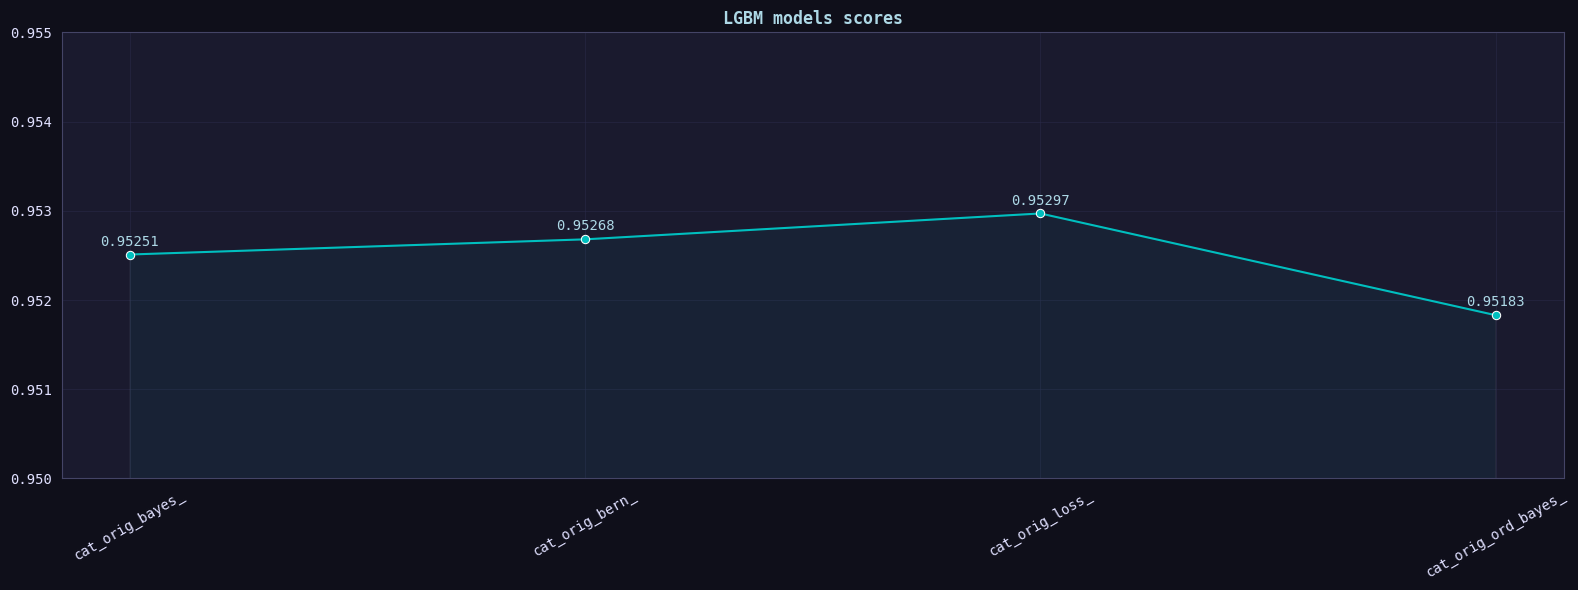

In [42]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_model_scores, marker='o')

ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.05)
ax.set_title('LGBM models scores', fontweight='semibold')
ax.tick_params('x', rotation=30)
ax.set_ylim(0.95, 0.955)

for i, s in enumerate(all_model_scores.values()):
    ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

plt.tight_layout()
plt.show()

cat_orig_bayes__95251 saved!


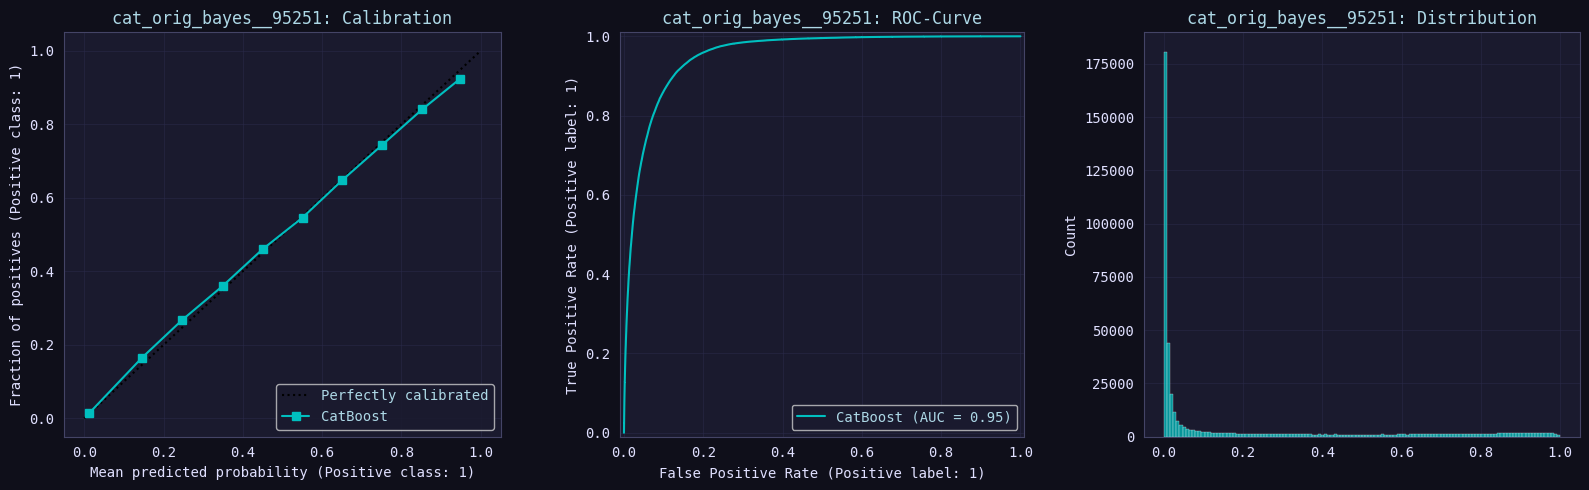


cat_orig_bern__95268 saved!


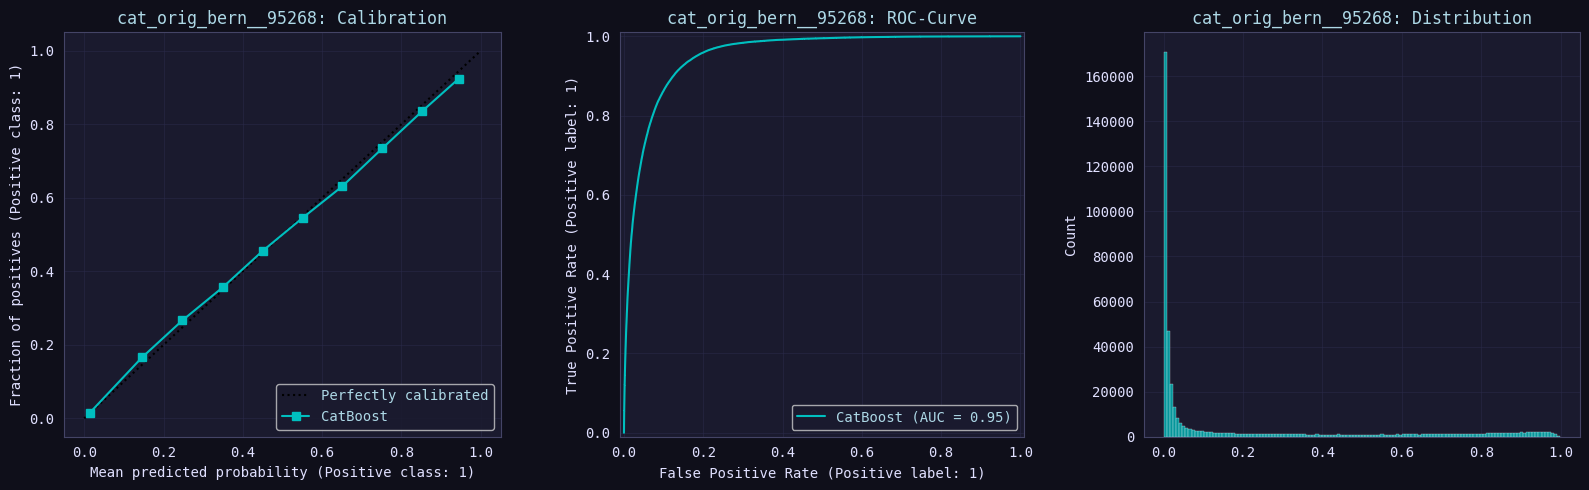


cat_orig_loss__95297 saved!


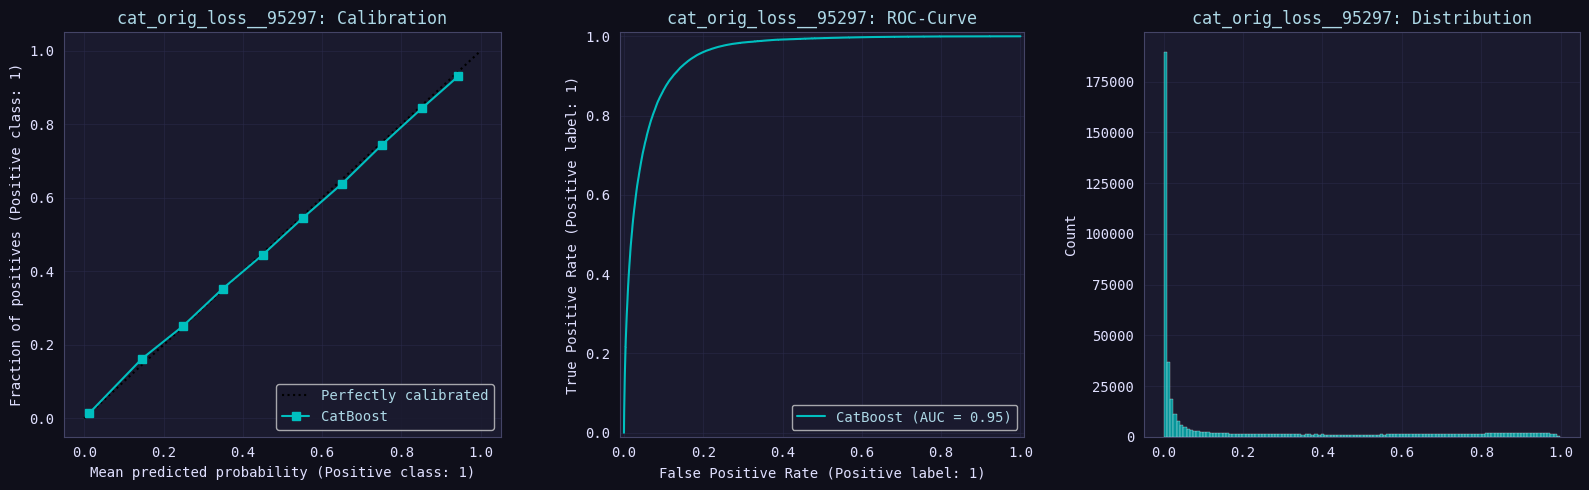


cat_orig_ord_bayes__95183 saved!


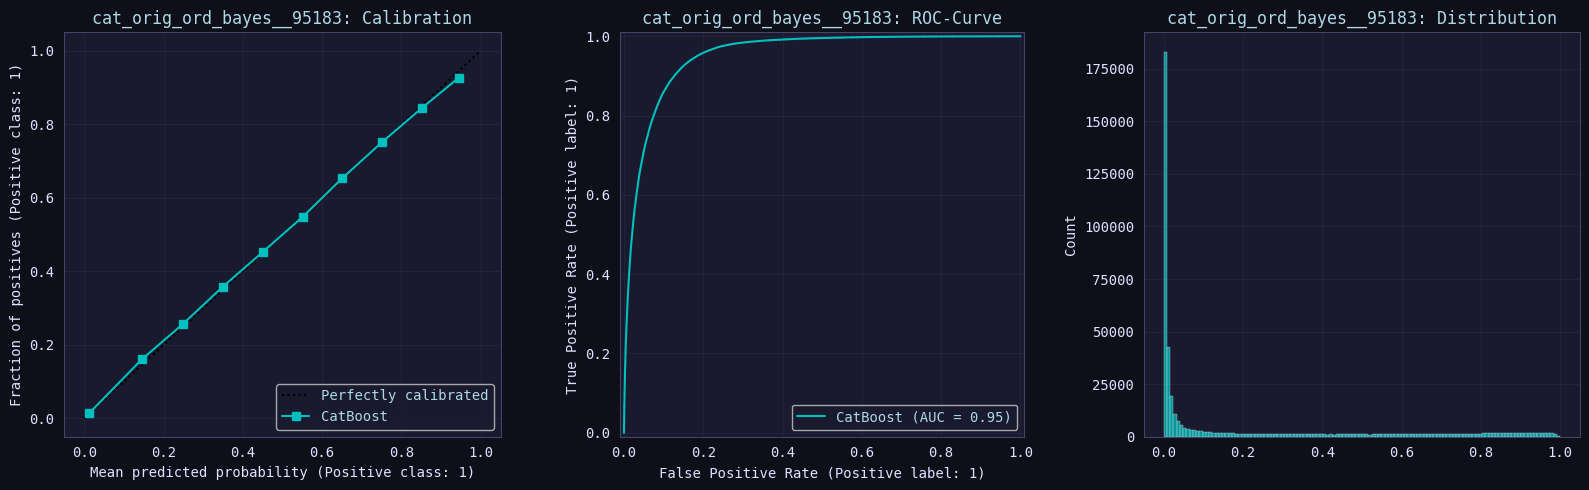

In [43]:
## -- Get oof predictions --
oof_predictions = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", y)
            print(f'{n} saved!')
            oof_predictions[n] = y

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train[TARGET], y, n_bins=10, name='CatBoost', ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train[TARGET], y, name='CatBoost', ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(y, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [44]:
pd.DataFrame(oof_predictions).head(10)

,cat_orig_bayes__95251,cat_orig_bern__95268,cat_orig_loss__95297,cat_orig_ord_bayes__95183
0,0.799852,0.722135,0.817154,0.776478
1,0.614732,0.771383,0.691928,0.561352
2,0.621466,0.582851,0.520430,0.715920
3,0.001718,0.003911,0.001015,0.001557
4,0.291459,0.224627,0.270574,0.264074
5,0.972422,0.973747,0.972300,0.956726
6,0.003462,0.002917,0.002529,0.004134
7,0.119429,0.113614,0.094329,0.109226
8,0.002521,0.004661,0.001848,0.001762
9,0.001174,0.001340,0.001459,0.000934


In [45]:
## -- Save test predictions/submissions --
test_predictions = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)
            test_predictions[n] = y

            submit[TARGET] = y
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

print()
pd.DataFrame(test_predictions).head(10)

cat_orig_bayes__95251 saved! (188165,)
cat_orig_bern__95268 saved! (188165,)
cat_orig_loss__95297 saved! (188165,)
cat_orig_ord_bayes__95183 saved! (188165,)



,cat_orig_bayes__95251,cat_orig_bern__95268,cat_orig_loss__95297,cat_orig_ord_bayes__95183
0,0.005393,0.004256,0.003438,0.005323
1,0.017341,0.006696,0.032445,0.016576
2,0.005574,0.003994,0.004260,0.005068
3,0.190028,0.180688,0.192089,0.205036
4,0.845396,0.882081,0.877225,0.809568
5,0.325895,0.469264,0.349751,0.325292
6,0.000873,0.002101,0.000206,0.000851
7,0.002708,0.005396,0.001733,0.002624
8,0.012677,0.010955,0.009789,0.009766
9,0.001324,0.001810,0.000438,0.001017


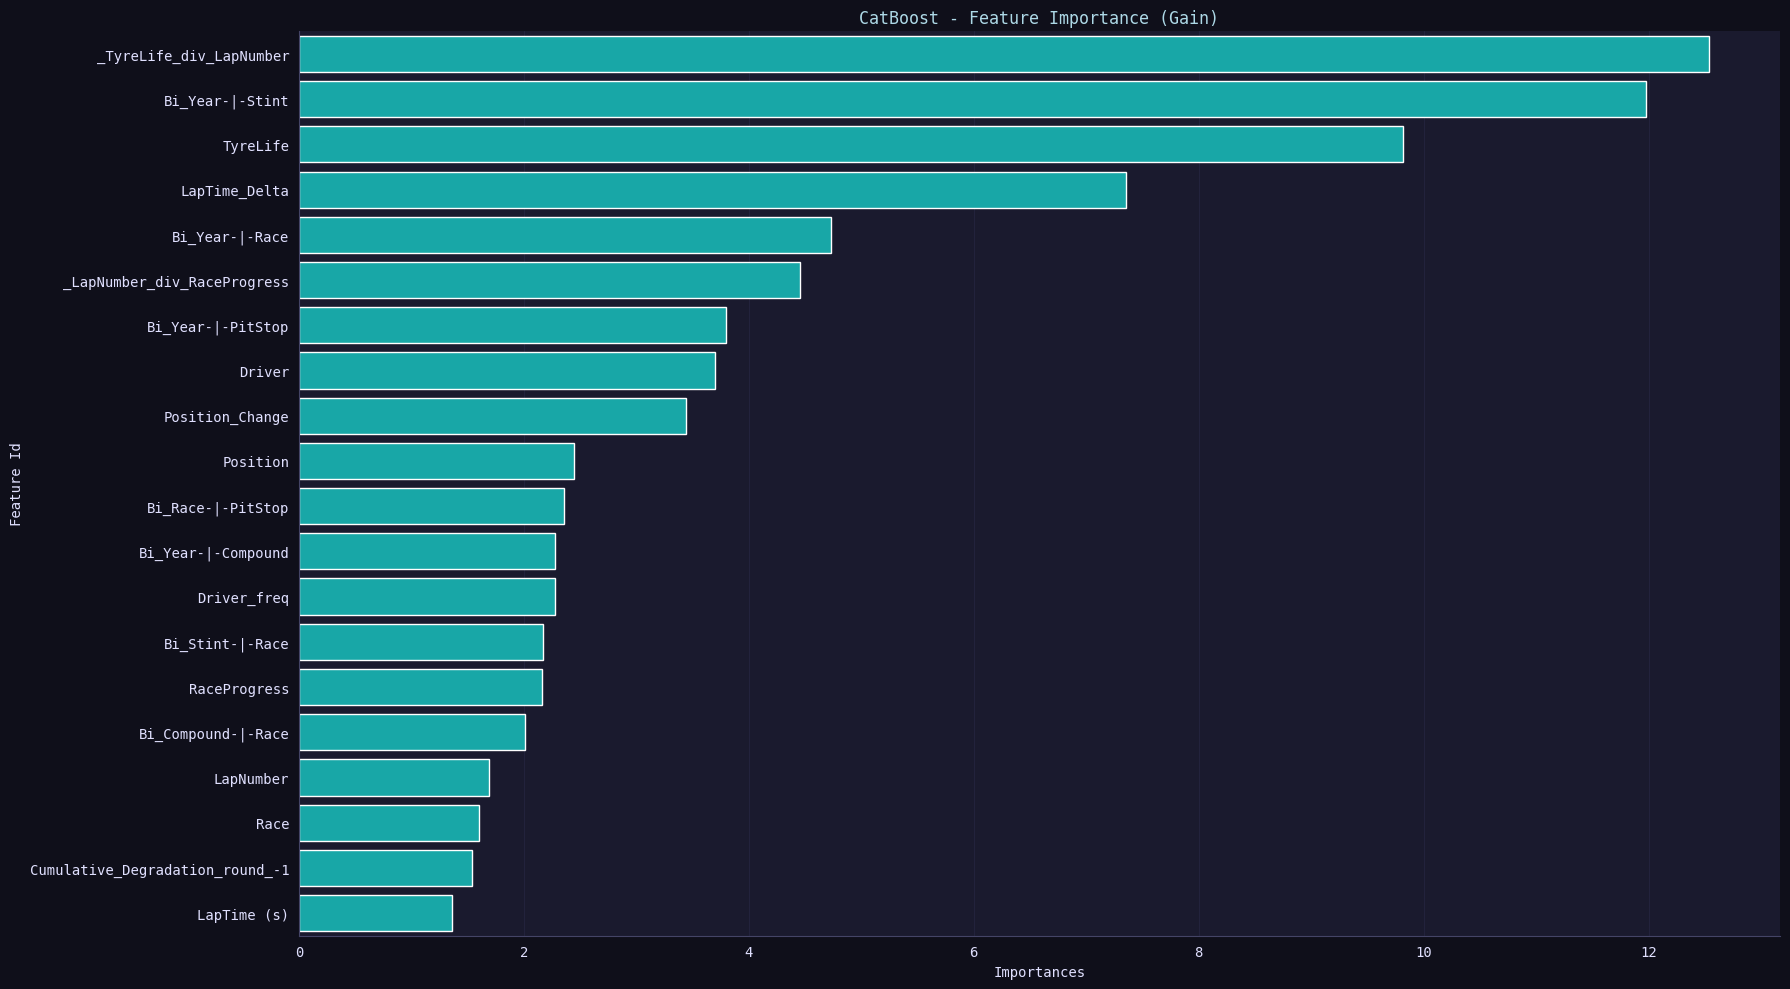

In [46]:
## -- Plot Feature Importances --
MAX = 20

get_model = all_model_predictions[list(all_model_predictions.keys())[0]]
feature_imp = get_model['model'].get_feature_importance(prettified=True)

plt.figure(figsize=(18, 10))
ax = sns.barplot(x='Importances', y='Feature Id', data=feature_imp[:MAX])

ax.set_title("CatBoost - Feature Importance (Gain)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()